<a href="https://colab.research.google.com/github/LauGabriela/ayda24/blob/Gabriela/perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Perpectron
### Laura Gabriela Romero Muñiz

In [ ]:
%%bash
pip install numpy

wget

In [ ]:
! nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
a =2

In [ ]:
! touch hola.py



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def step(v):
  if v >= 0:
    return 1
  return 0

In [ ]:
x = np.array([
  [.5, .9],
  [.3, .8],
  [.2, .95],
  [.7, .1],
  [.9, .2],
  [.8, .3]
])
t = np.array([
    [0],
    [0],
    [0],
    [1],
    [1],
    [1]
])

In [ ]:
#import numpy as np

def perceptron(x, t, eta=0.05, max_it=1000):
    f = False # Bandera de criterio de paro
    s = 0
    # Epocas
    np.random.seed(1)
    # Inicializacion de pesos
    w = np.array([[.1, .1]])#np.random.rand(len(t[1,:]), len(x[1,:]))
    b = np.array([[.1]])#np.random.rand(1, np.size(t[1,:]))

    while not f and s < max_it:
        f = True
        # Iterar para cada entrada de x
        for k in range(0, len(x[:,0])):
            v = np.dot(x[k, :], w.T) + b # v = x(k)*w^T + b
            y = step(v)
            # y = step(v)
            e = t[k] - y
            # e = t(k) - y
            if y != t[k]:
               w = w + (e*x[k, :]*eta) # w = w + e*x(k)*eta
               b = b + (e*eta)
               # b = b + e*eta
               f = False # Una falla, iniciamos de nuevo
        s = s + 1 # Incrementar epoca
    return w, b

In [ ]:
w,b = perceptron (x=x, t=t)

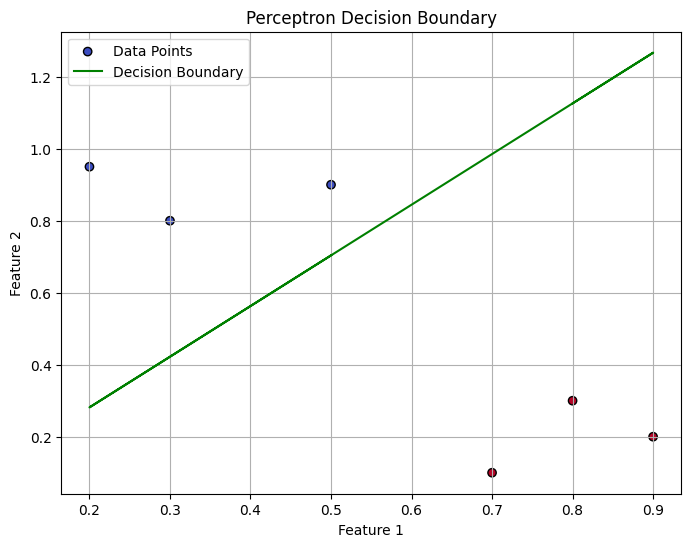

In [ ]:
import matplotlib.pyplot as plt

# Plot the data points
plt.figure(figsize=(8, 6))
plt.scatter(x[:, 0], x[:, 1], c=t.flatten(), cmap='coolwarm', marker='o', edgecolors='k', label='Data Points')

# Plot the decision boundary
# The decision boundary is given by w1*x1 + w2*x2 + b = 0
# Which can be rewritten as x2 = (-w1/w2)*x1 - (b/w2)
x2_boundary = (-w[0, 0] / w[0, 1]) * x[:, 0] - (b[0, 0] / w[0, 1])

plt.plot(x[:, 0], x2_boundary, color='green', linestyle='-', label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron Decision Boundary')
plt.legend()
plt.grid(True)
plt.show()

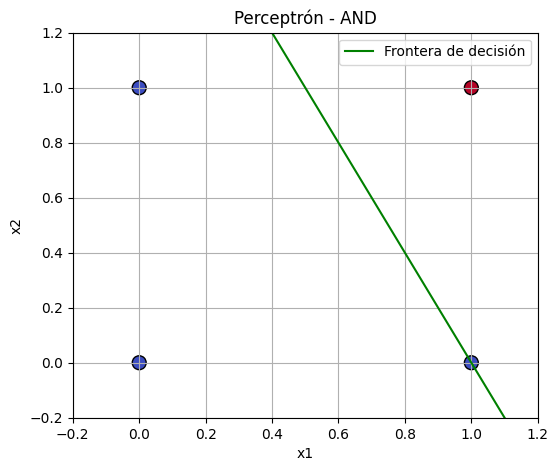

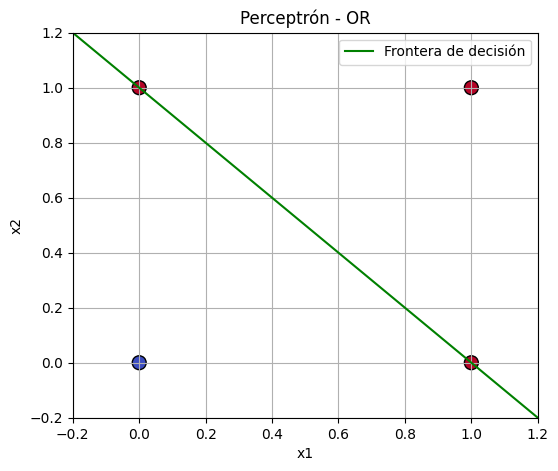

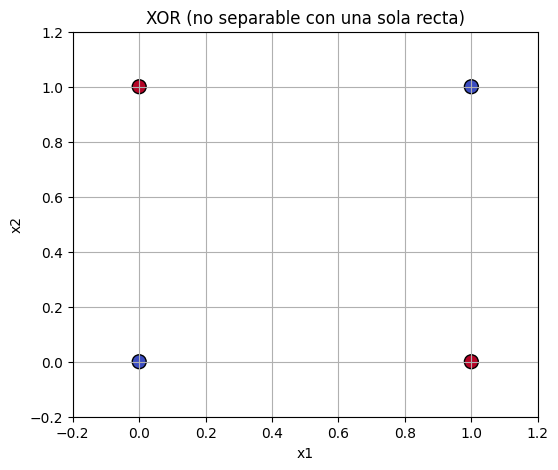

In [ ]:
import matplotlib.pyplot as plt

# ==========================
# Gráficas para AND y OR
# ==========================
def plot_decision_boundary(x, t, w, b, title):
    plt.figure(figsize=(6, 5))
    # Puntos
    plt.scatter(x[:, 0], x[:, 1], c=t.flatten(), cmap='coolwarm', edgecolors='k', s=100)
    # Recta: w1*x1 + w2*x2 + b = 0  ->  x2 = (-w1/w2)*x1 - b/w2
    x1_vals = np.linspace(-0.2, 1.2, 100)
    if w[0, 1] != 0:  # evitar división entre 0
        x2_vals = (-w[0, 0]/w[0, 1]) * x1_vals - (b[0, 0]/w[0, 1])
        plt.plot(x1_vals, x2_vals, 'g-', label="Frontera de decisión")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.xlim(-0.2, 1.2)
    plt.ylim(-0.2, 1.2)
    plt.grid(True)
    plt.legend()
    plt.show()

# AND
plot_decision_boundary(x_logic, t_and, w_and, b_and, "Perceptrón - AND")

# OR
plot_decision_boundary(x_logic, t_or, w_or, b_or, "Perceptrón - OR")


# ==========================
# XOR (no linealmente separable)
# ==========================
t_xor = np.array([[0], [1], [1], [0]])  # salida XOR

plt.figure(figsize=(6, 5))
plt.scatter(x_logic[:, 0], x_logic[:, 1], c=t_xor.flatten(), cmap='coolwarm', edgecolors='k', s=100)
plt.title("XOR (no separable con una sola recta)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.grid(True)
plt.show()
